In [1]:
import subprocess, sys
subprocess.check_call([sys.executable, "-m", "pip", "install", "torch", "torchvision"])

0

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

print(torch.__version__)          # 예: 2.2.0
print(torch.cuda.is_available())  # GPU 사용 가능 여부: True / False

2.11.0+cpu
False


In [3]:
# 2-2. Tensor 생성하는 방법

import torch

a = torch.tensor([1, 2, 3, 4, 5])
print(a)          # tensor([1, 2, 3, 4, 5])
print(a.dtype)    # torch.int64

b = torch.tensor([1.0, 2.0, 3.0])
print(b.dtype)    # torch.float32

torch.zeros((3, 3))      # 0으로 채운 3×3
torch.ones((2, 4))       # 1로 채운 2×4
torch.rand((3, 3))       # 0~1 난수
torch.arange(0, 10, 2)  # [0, 2, 4, 6, 8]

print(b.shape)    # torch.Size([3])
print(b.ndim)     # 1

tensor([1, 2, 3, 4, 5])
torch.int64
torch.float32
torch.Size([3])
1


In [4]:
# 2-3. NumPy 배열 ↔ Tensor 변환
import numpy as np
import torch

# NumPy → Tensor
arr = np.array([1, 2, 3])
tensor = torch.from_numpy(arr)
print(tensor)  # tensor([1, 2, 3])

# Tensor → NumPy
arr2 = tensor.numpy()
print(arr2)    # [1 2 3]

tensor([1, 2, 3])
[1 2 3]


In [5]:
# 2-4. GPU로 Tensor 올리기

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"사용 장치: {device}")

# Tensor를 GPU로 이동
tensor = torch.tensor([1.0, 2.0, 3.0]).to(device)
print(tensor)

# 모델이나 데이터도 같은 방식으로 이동 가능:
# model = model.to(device)
# X_batch = X_batch.to(device)

사용 장치: cpu
tensor([1., 2., 3.])


In [6]:
# 3-2. PyTorch — 명령형 (클래스로 직접 설계)
import torch.nn as nn

class MyModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(784, 128)
        self.dropout = nn.Dropout(0.3)
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, 10)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.relu(self.fc2(x))
        x = self.fc3(x)
        return x

model = MyModel()

In [7]:
# 4-3. 모델 구조 확인
model = MyModel()
print(model)

total = sum(p.numel() for p in model.parameters())
print(f"전체 파라미터 수: {total:,}")

MyModel(
  (fc1): Linear(in_features=784, out_features=128, bias=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc2): Linear(in_features=128, out_features=64, bias=True)
  (fc3): Linear(in_features=64, out_features=10, bias=True)
  (relu): ReLU()
)
전체 파라미터 수: 109,386


In [ ]:
# MNIST 데이터 준비 (섹션 5 학습 루프용)
from torchvision import datasets, transforms
import numpy as np

train_data = datasets.MNIST(root="./data", train=True, download=True)
X_train = train_data.data.numpy().reshape(-1, 784).astype(np.float32) / 255.0
y_train = train_data.targets.numpy()

print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")

100.0%
100.0%
100.0%
100.0%

X_train: (60000, 784), y_train: (60000,)


In [9]:
# 5-2. Dataset & DataLoader
from torch.utils.data import TensorDataset, DataLoader
import torch

X_tensor = torch.tensor(X_train, dtype=torch.float32)
y_tensor = torch.tensor(y_train, dtype=torch.long)

dataset = TensorDataset(X_tensor, y_tensor)
dataloader = DataLoader(dataset, batch_size=64, shuffle=True)

In [10]:
# 5-3. 손실 함수와 옵티마이저 설정
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [11]:
# 5-4. 전체 학습 루프
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"
model = model.to(device)

train_losses = []

for epoch in range(20):
    model.train()
    running_loss = 0.0

    for X_batch, y_batch in dataloader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()       # 1. 기울기 초기화 (반드시 먼저!)
        output = model(X_batch)     # 2. 순전파 (Forward)
        loss = criterion(output, y_batch)  # 3. 손실 계산
        loss.backward()             # 4. 역전파 (Backward)
        optimizer.step()            # 5. 가중치 업데이트

        running_loss += loss.item()

    avg_loss = running_loss / len(dataloader)
    train_losses.append(avg_loss)
    print(f"Epoch {epoch+1:2d}/20 — Loss: {avg_loss:.4f}")

Epoch  1/20 — Loss: 0.3946
Epoch  2/20 — Loss: 0.1809
Epoch  3/20 — Loss: 0.1361
Epoch  4/20 — Loss: 0.1157
Epoch  5/20 — Loss: 0.1014
Epoch  6/20 — Loss: 0.0887
Epoch  7/20 — Loss: 0.0831
Epoch  8/20 — Loss: 0.0768
Epoch  9/20 — Loss: 0.0701
Epoch 10/20 — Loss: 0.0666
Epoch 11/20 — Loss: 0.0628
Epoch 12/20 — Loss: 0.0579
Epoch 13/20 — Loss: 0.0543
Epoch 14/20 — Loss: 0.0557
Epoch 15/20 — Loss: 0.0525
Epoch 16/20 — Loss: 0.0488
Epoch 17/20 — Loss: 0.0493
Epoch 18/20 — Loss: 0.0448
Epoch 19/20 — Loss: 0.0439
Epoch 20/20 — Loss: 0.0459


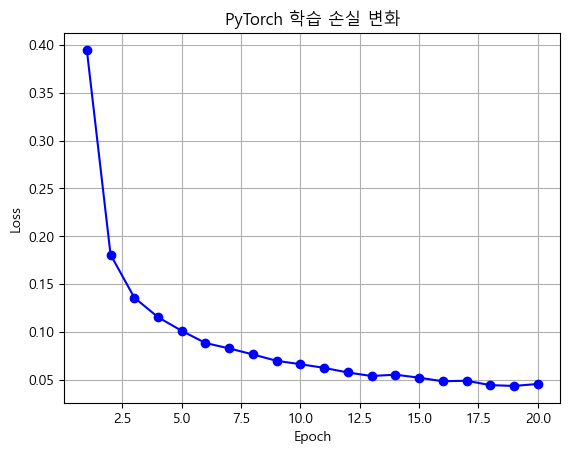

In [12]:
# 5-5. 학습 곡선 시각화

import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams["font.family"] = "Malgun Gothic"
matplotlib.rcParams["axes.unicode_minus"] = False

plt.plot(range(1, 21), train_losses, marker="o", color="blue")
plt.title("PyTorch 학습 손실 변화")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

In [13]:
# 6-1. torchvision으로 MNIST 데이터 불러오기

from torchvision import datasets, transforms
from torch.utils.data import DataLoader

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = datasets.MNIST(root="./data", train=True,
                                transform=transform, download=True)
test_dataset  = datasets.MNIST(root="./data", train=False,
                                transform=transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=64, shuffle=False)

In [14]:
# 6-2. 모델 설계 및 학습

import torch.nn.functional as F

class MNISTModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(784, 256)
        self.fc2 = nn.Linear(256, 128)
        self.fc3 = nn.Linear(128, 10)
        self.dropout = nn.Dropout(0.3)

    def forward(self, x):
        x = x.view(-1, 784)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

model = MNISTModel().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

for epoch in range(10):
    model.train()
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        loss = criterion(model(X_batch), y_batch)
        loss.backward()
        optimizer.step()
    print(f"Epoch {epoch+1}/10 완료")

Epoch 1/10 완료
Epoch 2/10 완료
Epoch 3/10 완료
Epoch 4/10 완료
Epoch 5/10 완료
Epoch 6/10 완료
Epoch 7/10 완료
Epoch 8/10 완료
Epoch 9/10 완료
Epoch 10/10 완료


테스트 정확도: 0.9759


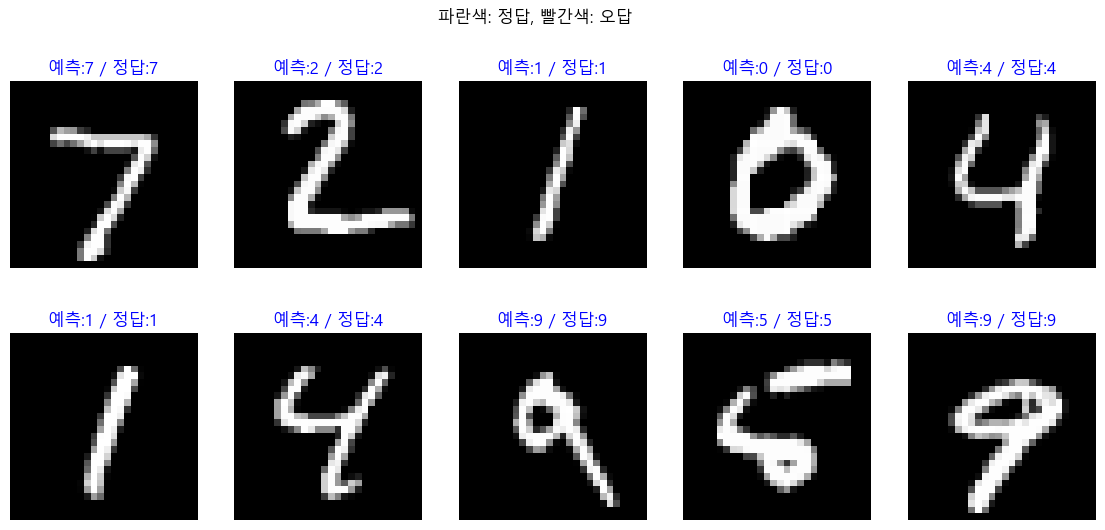

In [15]:
# 6-4. 정확도 평가 및 시각화

import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams["font.family"] = "Malgun Gothic"
matplotlib.rcParams["axes.unicode_minus"] = False

model.eval()
correct = 0
total = 0

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        output = model(X_batch)
        preds = output.argmax(dim=1)
        correct += (preds == y_batch).sum().item()
        total += y_batch.size(0)

print(f"테스트 정확도: {correct / total:.4f}")

test_images, test_labels = next(iter(test_loader))
model.eval()
with torch.no_grad():
    preds = model(test_images.to(device)).argmax(dim=1).cpu()

fig, axes = plt.subplots(2, 5, figsize=(14, 6))
for i, ax in enumerate(axes.flat):
    ax.imshow(test_images[i].squeeze(), cmap="gray")
    color = "blue" if preds[i] == test_labels[i] else "red"
    ax.set_title(f"예측:{preds[i].item()} / 정답:{test_labels[i].item()}", color=color)
    ax.axis("off")
plt.suptitle("파란색: 정답, 빨간색: 오답")
plt.show()